## CS310 Natural Language Processing
## Lab 5: Pretraining

In this lab, we will practice building a complete pretraining pipeline for a minimal GPT-2 model. The code for this lab is adopted from [LLMs-from-scratch (ch 05)](https://github.com/rasbt/LLMs-from-scratch/tree/main/ch05).

Install `torch` and `tiktoken` before getting started.
```bash
pip install torch torchvision
pip install tiktoken
```

## T0. Initialize Model

We use the code from the previous lab to initialize `GPTModel`.

In [3]:
import sys
import torch
from utils import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
# model.eval();

Use the tokenizer provided by `tiktoken`.

In [4]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

def text_to_token_ids(text: str, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

# Test
token_ids1 = text_to_token_ids("The world is a beautiful place", tokenizer)
print(token_ids1)

token_ids2 = text_to_token_ids("I really like the sweet pepper", tokenizer)
print(token_ids2)

token_ids3 = text_to_token_ids("How about some anomalous words", tokenizer)
print(token_ids3)

tensor([[ 464,  995,  318,  257, 4950, 1295]])
tensor([[   40,  1107,   588,   262,  6029, 13385]])
tensor([[ 2437,   546,   617, 26921,   516,  2456]])


It can be seen that the third sentence of 5 words is tokenized into 6 tokens.

Let's see what they correspond to.

In [5]:
token_ids3_list = token_ids3.squeeze(0).tolist()
print(token_ids3_list)

for tok_id in token_ids3_list:
    sys.stdout.write(tokenizer.decode([tok_id]) + "_")

[2437, 546, 617, 26921, 516, 2456]
How_ about_ some_ anomal_ous_ words_

The word `"anomalous"` is tokenized into `["anomal", "ous"]`

---

## T1. Computing Cross-Entropy Loss

Next, we will implement the `cross-entropy` loss for the next-token prediction task.

Let's consider an input tensor containing the token ids for two sentences, i.e., `batch_size=2`. 

In [6]:
inputs = torch.tensor([[464, 995, 318, 257], # "The word is a"
                       [40, 1107, 588, 262]]) # "I readlly like the"

targets = torch.tensor([[995, 318, 257, 4950],
                        [1107, 588, 262, 6029]])

print(inputs.shape)
print(targets.shape)

torch.Size([2, 4])
torch.Size([2, 4])


After feeding inputs to the model, we can get the `logits` vectors for the two input sentences.

In [7]:
with torch.no_grad():
    logits = model(inputs)

print(logits.shape)

torch.Size([2, 4, 50257])


Logits are not probabilities yet, so we use `softmax` to convert the logits vectors into probability distributions.

In [8]:
probs = torch.softmax(logits, dim=-1) # apply softmax on the last dimension
print(probs.shape)

torch.Size([2, 4, 50257])


For each of the 50257-dim probability vectors, let's use `argmax` to find the position of the highest probability score, which is the predicted token ID.

In [9]:
pred_token_ids = torch.argmax(probs, dim=-1)
print(pred_token_ids.shape)

torch.Size([2, 4])


It is $2\times 4$, same as the `input`'s shape.

But the predictions don't make sense:

In [10]:
print("Predicted outputs 1:", token_ids_to_text(pred_token_ids[0], tokenizer))
print("Predicted outputs 2:", token_ids_to_text(pred_token_ids[1], tokenizer))

Predicted outputs 1:  Keyoenix handlers294
Predicted outputs 2:  flowed InitifaithCopy


The predictions are very different from the ground truth `target` tokens:

In [11]:
print("Target 1:", token_ids_to_text(targets[0], tokenizer))
print("Target 2:", token_ids_to_text(targets[1], tokenizer))

Target 1:  world is a beautiful
Target 2:  really like the sweet


This is because the model wasn't trained yet. 

We need to use the distance between the predicted probability distributions and the `targets` as the training loss, and this distance is commonly measured using `cross-entropy`. 

We can look at the current probabilities for the `target` tokens:

In [12]:
target_probs_1 = probs[0, [0,1,2,3], targets[0]]
print(target_probs_1)

target_probs_2 = probs[1, [0,1,2,3], targets[1]]
print(target_probs_2)


tensor([7.6919e-06, 1.8792e-05, 9.7180e-06, 1.9871e-05])
tensor([7.6030e-06, 4.1396e-05, 9.6424e-06, 1.6399e-05])


These probability values are very small, and we want to maximize them, i.e., to push them close to 1. 

In mathematical optimization, it is easier to maximize the logarithm of probability, $\log(p)$. In practice, we can compute the mean of the log probabilities of all the targets in the batch, $\frac{1}{N}\sum\log(p)$:

In [13]:
log_probs = torch.log(torch.cat([target_probs_1, target_probs_2]))
mean_log_probs = torch.mean(log_probs)

print(mean_log_probs)

tensor(-11.1840)


In deep learning, instead of maximizing the mean log probability, it is a convention to minimize the *negative* mean log probability: $-\frac{1}{N}\sum\log(p)$

In [14]:
neg_mean_log_probs = -mean_log_probs
print(neg_mean_log_probs)

tensor(11.1840)


`PyTorch` provides a function  `nn.functional.cross_entropy` (or, the `nn.CrossEntropyLoss` module) to compute the above loss, taking the `logits` and `targets` as inputs.

In [ ]:
import torch.nn.functional as F

# The following call will raise an unmatched shape error
# nll_loss = F.cross_entropy(logits, targets)

# We need to flatten the two inputs
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()

print(logits_flat.shape)
print(targets_flat.shape)

# Try uncommenting the following and run
# nll_loss = F.cross_entropy(logits_flat, targets_flat)
# print(nll_loss)

torch.Size([8, 50257])
torch.Size([8])
tensor(11.1840)


`cross_entropy` has an argument `reduction="none"`, which means the loss is not averaged over the batch.

**Question**: What variable that we computed before saves the same values as `nll_loss_all` in the following cell?

In [23]:
nll_loss_all = F.cross_entropy(logits_flat, targets_flat, reduction="none")
print(nll_loss_all)

tensor([11.7753, 10.8821, 11.5415, 10.8262, 11.7870, 10.0923, 11.5493, 11.0183])


## T2. Loading the Data

A toy text dataset `the-verdict.txt` is provided. 

In [25]:
file_path = "the-verdict.txt"

with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

Let's examine the number of tokens in it

In [26]:
total_tokens = len(tokenizer.encode(text_data))
print("# of Tokens:", total_tokens)

# of Tokens: 5145


Next, we wrap the raw `text_data` with the provided train and validate data loaders.

In [27]:
from utils import create_dataloader_v1

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

A small `batch_size` is used to reduce the computational cost.

We can check the shape of the batch from data loaders.

In [30]:
count = 0
for batch in train_loader:
    count += 1
    inputs, targets = batch
    print(inputs.shape, targets.shape)
    if count >= 1:
        break

torch.Size([2, 256]) torch.Size([2, 256])


It can be seen that the returned `batch` is a tuple of two tensors: `inputs` and `targets`, whose shape is `batch_size`(2) by `context_length` (256).

## T3. Training

To help begin with the training, we first define two helper functions for calculating the loss:

In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
    """
    Calculate the cross-entropy loss of a given batch
    """
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    ### START YOUR CODE ###
    # Run forward pass to get the logits, and then compute the loss
    logits = model(input_batch)
    loss = F.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    ### END YOUR CODE
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    """
    Calculate the average loss for a user-specified number of batches in a data loader
    """
    total_loss = 0.0

    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            ### START YOUR CODE ###
            # Call calc_loss_batch to get the loss, and then add it to the total loss
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
            ### END YOUR CODE ###
        else:
            break
    
    return total_loss / num_batches

If your machine has a CUDA-supported GPU, specify `device="cuda"`, otherwise use `device="cpu"`.

Note that in the above cell, all the tensors are moved to the same device before calculating the loss.

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using {device} device.")

torch.manual_seed(123)
model.to(device)
with torch.no_grad(): # # Disable gradient tracking, because we are not training
    ### START YOUR CODE ###
    # Call calc_loss_loader on train_loader and val_loader, respectively (with default num_batches)
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
    ### END YOUR CODE ###

print(f"Train Loss: {train_loss:.6f}, Validation Loss: {val_loss:.6f}")

Using cpu device.
Train Loss: 10.989524, Validation Loss: 10.974542


Next, we define a `train_model` function to implement training loop.

In [ ]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset gradients from the previous iteration

            ### START YOUR CODE ###
            # Forward pass, call calc_loss_batch to get the loss
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            ### END YOUR CODE ###

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            # Update the number of tokens seen
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
    
    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        ### START YOUR CODE ###
        # Call calc_loss_loader on train_loader and val_loader, respectively (with the specified num_batches)
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
        ### END YOUR CODE ###
    model.train()
    return train_loss, val_loss

Finally, let's start training!

In [37]:
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.781, Val loss 9.933
Ep 1 (Step 000005): Train loss 8.111, Val loss 8.339
Ep 2 (Step 000010): Train loss 6.661, Val loss 7.048
Ep 2 (Step 000015): Train loss 5.961, Val loss 6.616
Ep 3 (Step 000020): Train loss 5.726, Val loss 6.600
Ep 3 (Step 000025): Train loss 5.201, Val loss 6.348
Ep 4 (Step 000030): Train loss 4.417, Val loss 6.278
Ep 4 (Step 000035): Train loss 4.069, Val loss 6.226
Ep 5 (Step 000040): Train loss 3.732, Val loss 6.160
Ep 6 (Step 000045): Train loss 2.850, Val loss 6.179
Ep 6 (Step 000050): Train loss 2.427, Val loss 6.141
Ep 7 (Step 000055): Train loss 2.104, Val loss 6.134
Ep 7 (Step 000060): Train loss 1.882, Val loss 6.233
Ep 8 (Step 000065): Train loss 1.320, Val loss 6.238
Ep 8 (Step 000070): Train loss 0.985, Val loss 6.242
Ep 9 (Step 000075): Train loss 0.717, Val loss 6.293
Ep 9 (Step 000080): Train loss 0.541, Val loss 6.393
Ep 10 (Step 000085): Train loss 0.391, Val loss 6.452
Training completed in 1.64 minutes.


After the training is done, we can plot the training and validation losses.

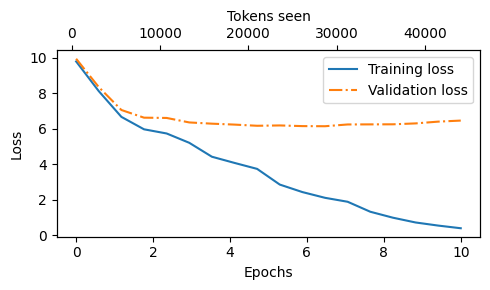

In [39]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)